<a href="https://colab.research.google.com/github/HEMANTH21-git/CodeAlpha_EDA_Project/blob/main/Task_3_Data_visualization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/cars dataset.csv.zip", encoding='latin 1')

In [ ]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [ ]:
df_clean = df.copy()
df_clean['HorsePower'] = df_clean['HorsePower'].str.extract(r'(\d+)')
df_clean['HorsePower'] = pd.to_numeric(df_clean['HorsePower'], errors='coerce')

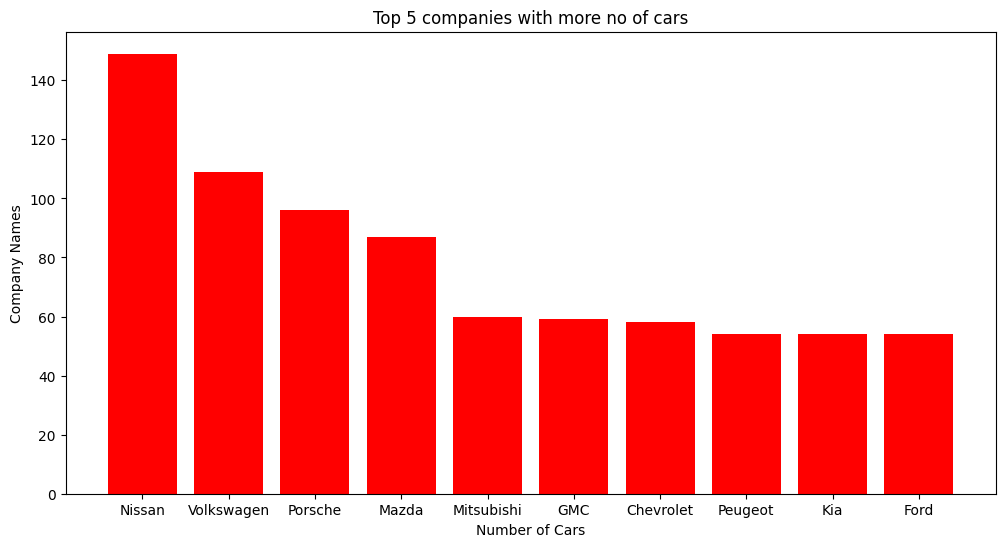

In [ ]:
top_companies = df_clean['Company Names'].value_counts().head(10)
plt.figure(figsize=(12,6))
plt.bar(top_companies.index, top_companies.values,color='red')
plt.xticks(rotation = 0)
plt.yticks(rotation = 0)
plt.title('Top 5 companies with more no of cars')
plt.xlabel('Number of Cars')
plt.ylabel('Company Names')

plt.show()



This bar graph shows the companies with the highest number of vehicle models in the dataset. Companies appearing at the top have a stronger representation in the dataset compared to others.

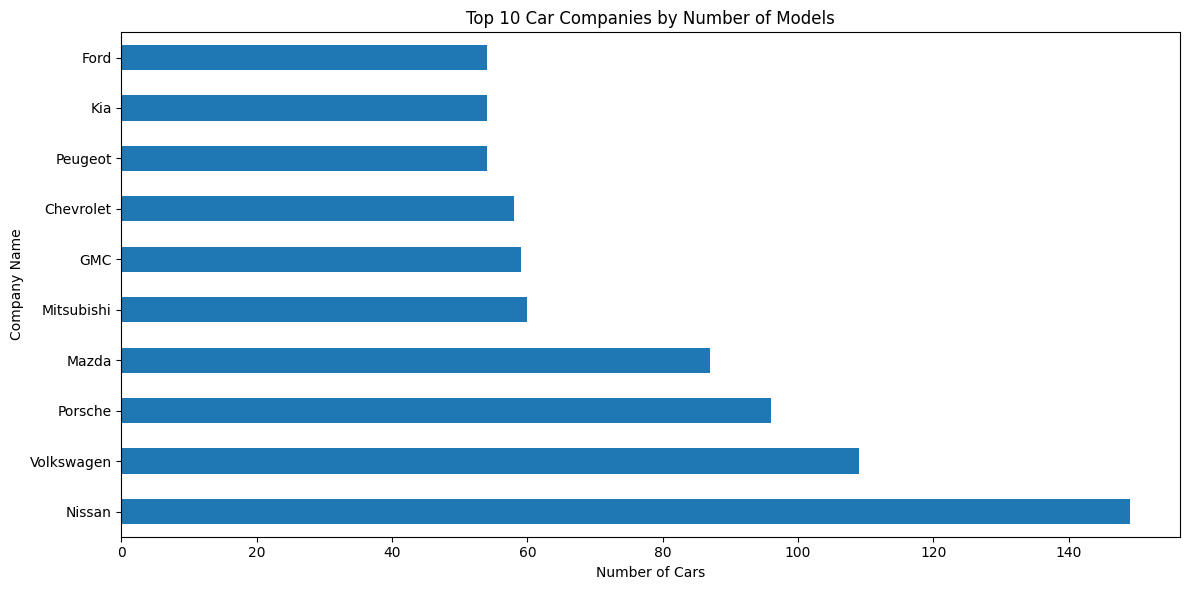

In [ ]:
top_companies = df_clean['Company Names'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_companies.plot(kind='barh')

plt.title('Top 10 Car Companies by Number of Models')
plt.xlabel('Number of Cars')
plt.ylabel('Company Name')

plt.tight_layout()
plt.show()



This chart shows the companies with the highest number of vehicle models in the dataset. Companies appearing at the top have a stronger representation in the dataset compared to others.

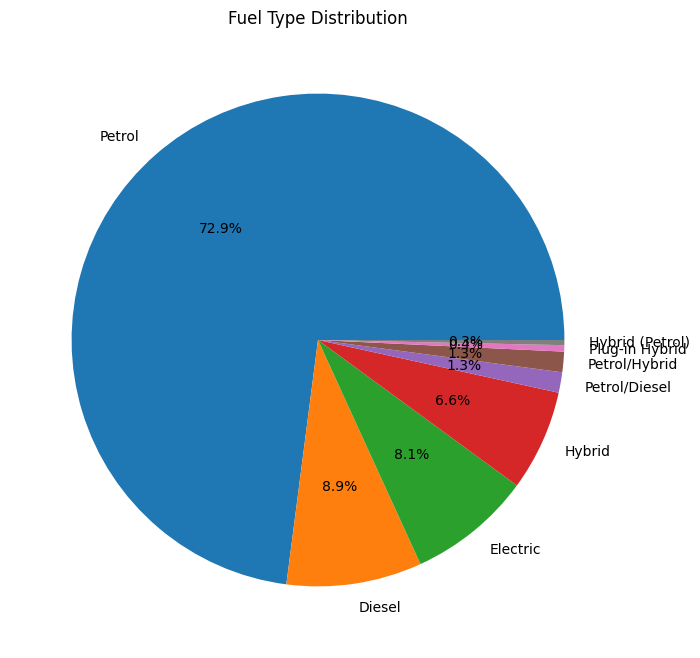

In [ ]:
fuel_counts = df_clean['Fuel Types'].value_counts().head(8)

plt.figure(figsize=(8,8))

fuel_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Fuel Type Distribution')
plt.ylabel('')

plt.show()



The chart shows the proportion of different fuel types in the dataset and helps identify which fuel technology is most common.

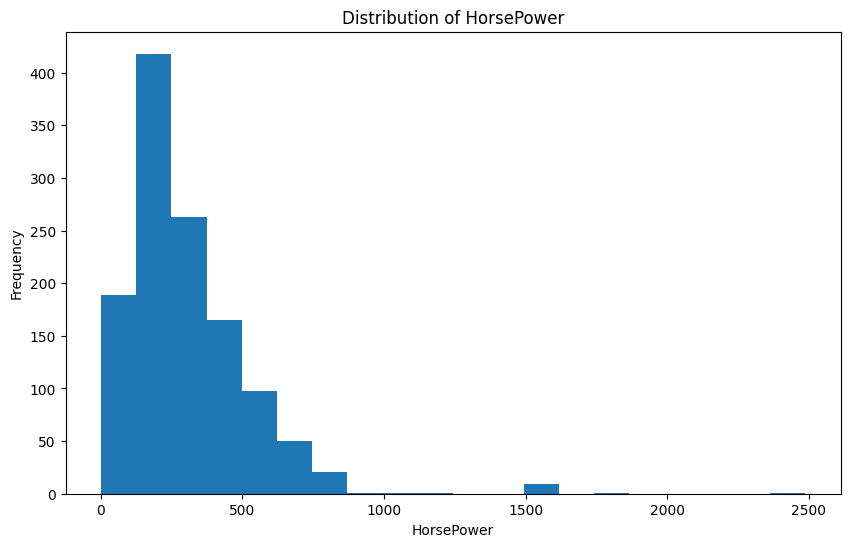

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df_clean['HorsePower'],bins=20)
plt.title("Distribution of HorsePower")
plt.xlabel("HorsePower")
plt.ylabel("Frequency")

plt.show()



Most vehicles are concentrated within a specific horsepower range, while only a few vehicles belong to the high-performance segment.

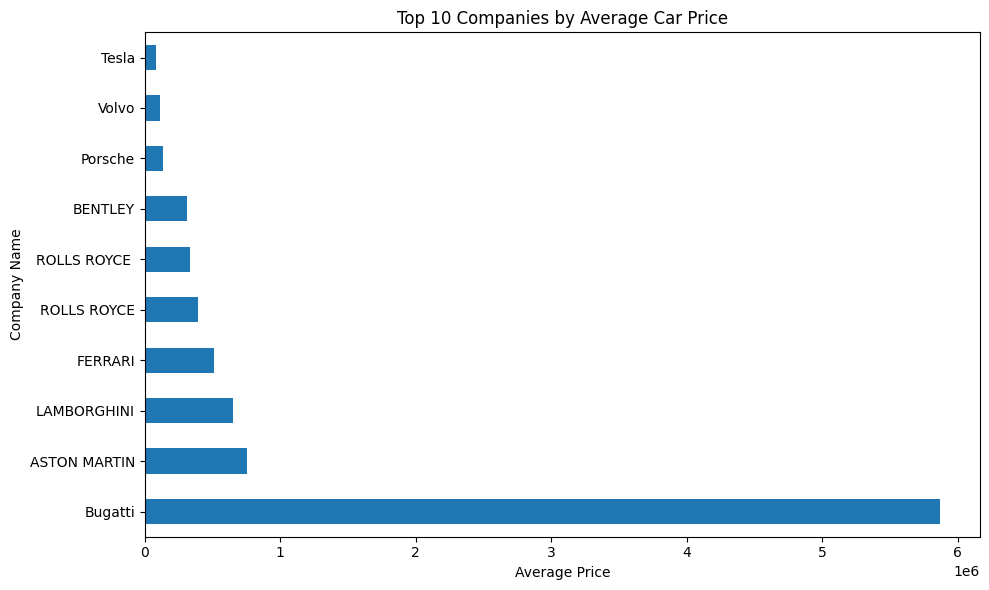

In [ ]:
temp_df_for_prices = df_clean.copy()

temp_df_for_prices['Cars Prices'] = (
    temp_df_for_prices['Cars Prices']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

temp_df_for_prices['Cars Prices'] = temp_df_for_prices['Cars Prices'].apply(
    lambda x: x.split('-')[0] if isinstance(x, str) else x
)

temp_df_for_prices['Cars Prices'] = pd.to_numeric(
    temp_df_for_prices['Cars Prices'], errors='coerce'
)

top_price_companies = (
    temp_df_for_prices.groupby('Company Names')['Cars Prices']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_price_companies.plot(kind='barh')

plt.title('Top 10 Companies by Average Car Price')
plt.xlabel('Average Price')
plt.ylabel('Company Name')

plt.tight_layout()
plt.show()

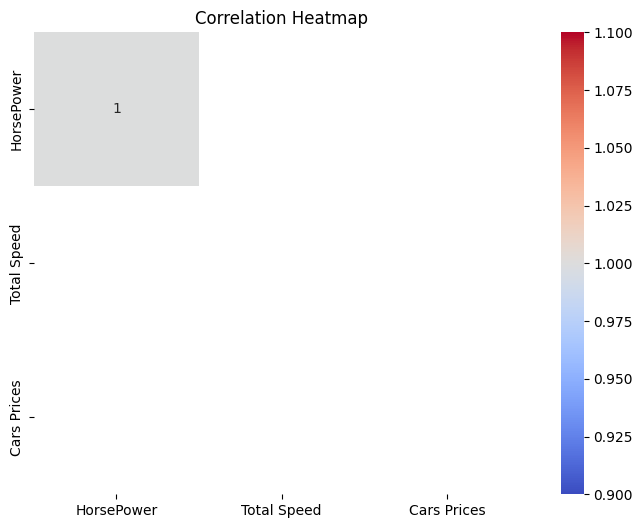

In [ ]:
corr_data = df_clean[['HorsePower','Total Speed','Cars Prices']].copy()

corr_data = corr_data.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()



The heatmap provides a quick overview of relationships between numerical variables and helps identify positive or negative correlations.

In [ ]:
print("Dataset Shape:", df_clean.shape)
print("Total Companies:", df_clean['Company Names'].nunique())
print("Total Fuel Types:", df_clean['Fuel Types'].nunique())

Dataset Shape: (1218, 11)
Total Companies: 37
Total Fuel Types: 23


# Conclusion

This project focused on visualizing automotive data to uncover meaningful patterns and trends. The visualizations highlighted company representation, vehicle performance, fuel type distribution, pricing trends, and relationships between key variables. Through these visual insights, complex data was presented in a simple and understandable manner, supporting better data-driven understanding and decision making.